# GAFIS — Fingerprint Dataset Analysis & Pix2Pix Dataset Generation

This notebook is organized into the pipeline stages described in the project review:

1. **Dataset Analysis** — stats, distributions, quality metrics on the raw SOCOFing images
2. **Preprocessing** — build the clean `target/` images (resize → CLAHE → normalize)
3. **Degradation Demo** — visualize mild/moderate/severe synthetic latent degradation
4. **PolyU Noise Library** — extract sensor noise maps from the PolyU dataset
5. **Full Dataset Generation** — loop over all 6,000 fingerprints, save `input/` + `target/` pairs
6. **Verification** — sample pairs + quality-metric comparison across the generated dataset

Each stage keeps the plots/tables you were already producing, so the report figures stay intact.

## 0. Imports & Paths

In [1]:
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

# ---------------------------
# Paths - EDIT THESE IF NEEDED
# ---------------------------
SOCOFING_ROOT = Path(
    r"C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\SocoFing_Real\Real\Real"
)
POLYU_ROOT = Path(
    r"C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages"
)
NOISE_LIB_DIR = Path("NoiseLibrary")

OUTPUT_ROOT = Path("dataset")
TARGET_DIR = OUTPUT_ROOT / "target"
INPUT_DIR = OUTPUT_ROOT / "input"

NOISE_LIB_DIR.mkdir(exist_ok=True)
TARGET_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256

random.seed(42)
np.random.seed(42)

## 1. Dataset Analysis

Basic stats, gender distribution, resolution distribution, and no-reference quality metrics on the raw SOCOFing images.

In [2]:
rows = []

for subject_folder in Path(SOCOFING_ROOT).iterdir():
    if not subject_folder.is_dir():
        continue

    subject = subject_folder.name
    gender = "Unknown"
    if "__M" in subject:
        gender = "Male"
    elif "__F" in subject:
        gender = "Female"

    for img_path in subject_folder.glob("*.BMP"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w = img.shape
        rows.append({"subject": subject, "gender": gender, "height": h, "width": w, "path": str(img_path)})

df = pd.DataFrame(rows)

print("Total Images :", len(df))
print("Total Subjects :", df["subject"].nunique())
print("\nGender Distribution")
print(df["gender"].value_counts())
print("\nResolution Statistics")
print(df[["height", "width"]].describe())

Total Images : 6000
Total Subjects : 600

Gender Distribution
gender
Male      4770
Female    1230
Name: count, dtype: int64

Resolution Statistics
            height        width
count  6000.000000  6000.000000
mean    104.430000    97.063333
std      16.638847    12.372476
min     103.000000    96.000000
25%     103.000000    96.000000
50%     103.000000    96.000000
75%     103.000000    96.000000
max     298.000000   241.000000


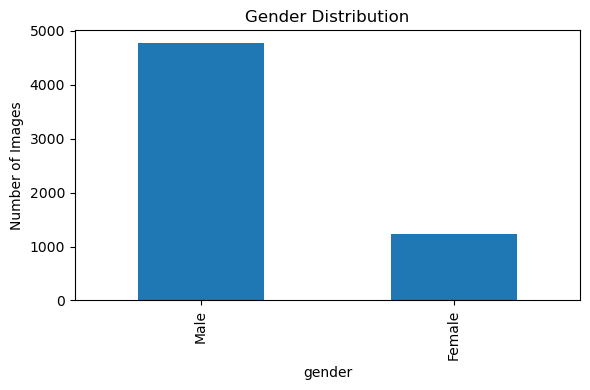

Male: 79.5%  Female: 20.5%


In [3]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 4))
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

male_pct = (gender_counts.get("Male", 0) / len(df)) * 100
female_pct = (gender_counts.get("Female", 0) / len(df)) * 100
print(f"Male: {male_pct:.1f}%  Female: {female_pct:.1f}%")

height  width
103     96       5956
298     241        44
dtype: int64


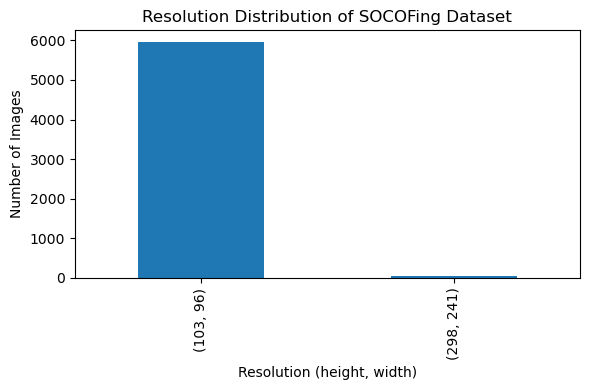

In [4]:
res_counts = df.groupby(["height", "width"]).size().sort_values(ascending=False)
print(res_counts.head(10))

plt.figure(figsize=(6, 4))
res_counts.head(10).plot(kind="bar")
plt.title("Resolution Distribution of SOCOFing Dataset")
plt.xlabel("Resolution (height, width)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

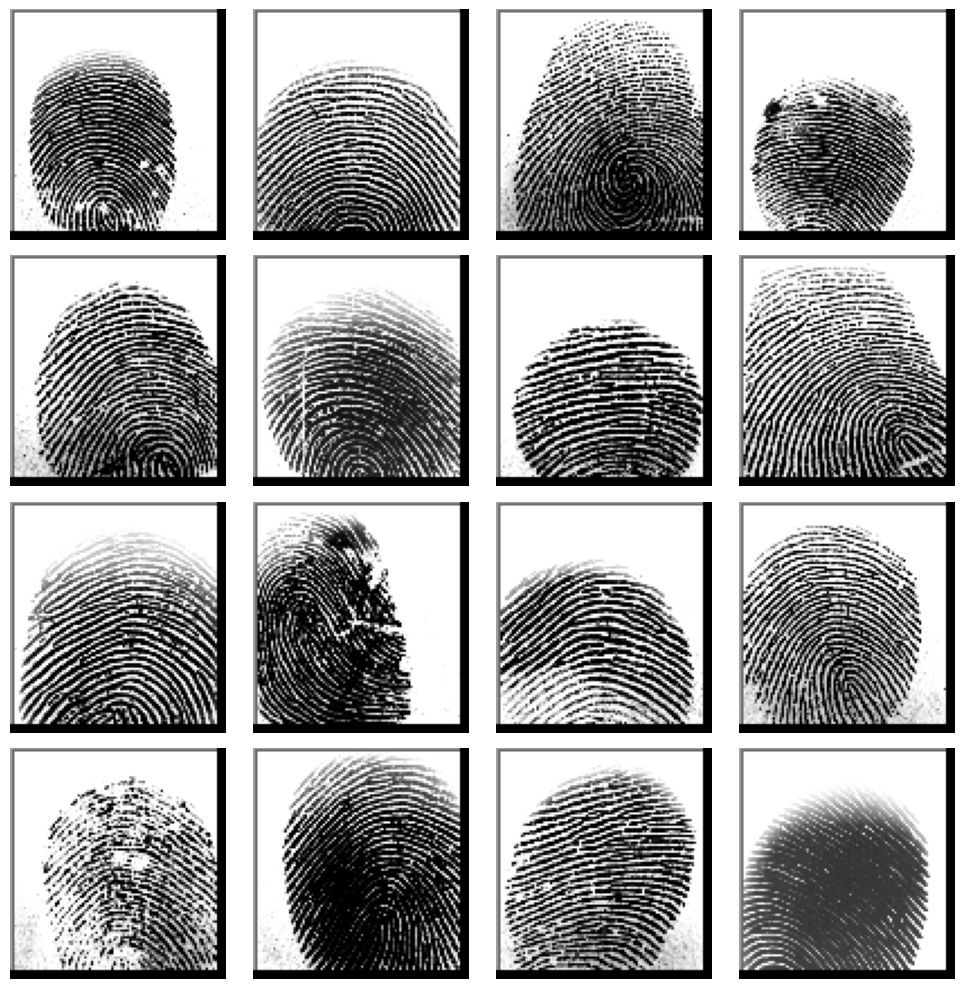

In [5]:
sample_paths = random.sample(list(df["path"]), 16)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, path in zip(axes.flatten(), sample_paths):
    img = cv2.imread(path, 0)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
def compute_metrics(img):
    mean_intensity = img.mean()
    contrast = img.std()
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    ent = entropy(hist.ravel() + 1)
    blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
    return {
        "MeanIntensity": round(float(mean_intensity), 2),
        "Contrast": round(float(contrast), 2),
        "Entropy": round(float(ent), 2),
        "BlurScore": round(float(blur_score), 2),
    }

quality_rows = []
for path in df["path"]:
    img = cv2.imread(path, 0)
    quality_rows.append(compute_metrics(img))

quality_df = pd.DataFrame(quality_rows)
quality_df.describe()

,MeanIntensity,Contrast,Entropy,BlurScore
count,6000.000000,6000.000000,6000.00000,6000.000000
mean,142.777365,103.808407,3.60917,58055.867248
std,22.955257,6.655565,0.40175,16871.983816
min,37.400000,71.620000,1.75000,4873.530000
25%,130.047500,100.737500,3.36750,47633.670000
50%,144.105000,105.285000,3.65000,59622.225000
75%,158.462500,108.240000,3.87000,69581.350000
max,220.480000,120.760000,4.79000,112282.170000


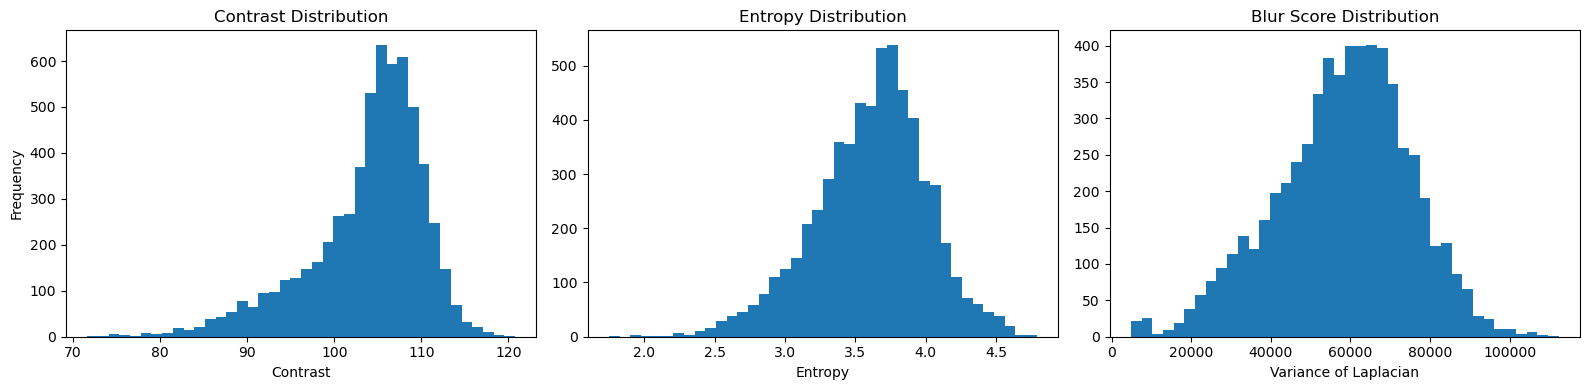

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(quality_df["Contrast"], bins=40)
axes[0].set_title("Contrast Distribution")
axes[0].set_xlabel("Contrast")
axes[0].set_ylabel("Frequency")

axes[1].hist(quality_df["Entropy"], bins=40)
axes[1].set_title("Entropy Distribution")
axes[1].set_xlabel("Entropy")

axes[2].hist(quality_df["BlurScore"], bins=40)
axes[2].set_title("Blur Score Distribution")
axes[2].set_xlabel("Variance of Laplacian")

plt.tight_layout()
plt.show()

## 2. Preprocessing — Building the Clean `target/` Images

Resize → CLAHE → normalize. This is the ground truth Pix2Pix will learn to reconstruct — **no degradation is applied here**.

C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\SocoFing_Real\Real\Real\262__M\262__M_Left_little_finger.BMP


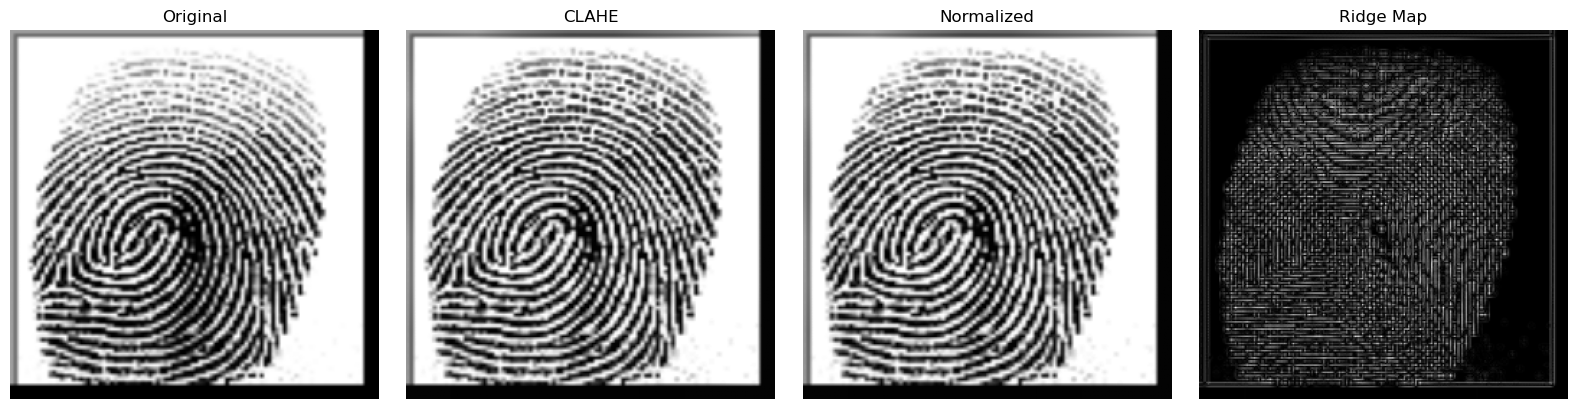

In [8]:
def preprocess(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img

sample_path = random.choice(list(df["path"]))
print(sample_path)

sample = cv2.imread(sample_path, 0)
clahe_only = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(cv2.resize(sample, (IMG_SIZE, IMG_SIZE)))
normalized = preprocess(sample)

edges = cv2.Laplacian(normalized, cv2.CV_64F)
edges = np.uint8(np.absolute(edges))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(cv2.resize(sample, (IMG_SIZE, IMG_SIZE)), cmap="gray"); ax[0].set_title("Original")
ax[1].imshow(clahe_only, cmap="gray"); ax[1].set_title("CLAHE")
ax[2].imshow(normalized, cmap="gray"); ax[2].set_title("Normalized")
ax[3].imshow(edges, cmap="gray"); ax[3].set_title("Ridge Map")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

In [9]:
before_metrics = compute_metrics(cv2.resize(sample, (IMG_SIZE, IMG_SIZE)))
after_metrics = compute_metrics(normalized)

preproc_df = pd.DataFrame([
    {"Stage": "Original (resized)", **before_metrics},
    {"Stage": "Preprocessed (CLAHE+Norm)", **after_metrics},
])
preproc_df

,Stage,MeanIntensity,Contrast,Entropy,BlurScore
0,Original (resized),155.51,91.40,4.64,2054.36
1,Preprocessed (CLAHE+Norm),154.65,88.82,4.71,2514.55


## 3. Degradation Demo — Synthetic Latent Generation

Applied to the **clean target**, not the raw original, so the demo matches what the full pipeline will actually do.

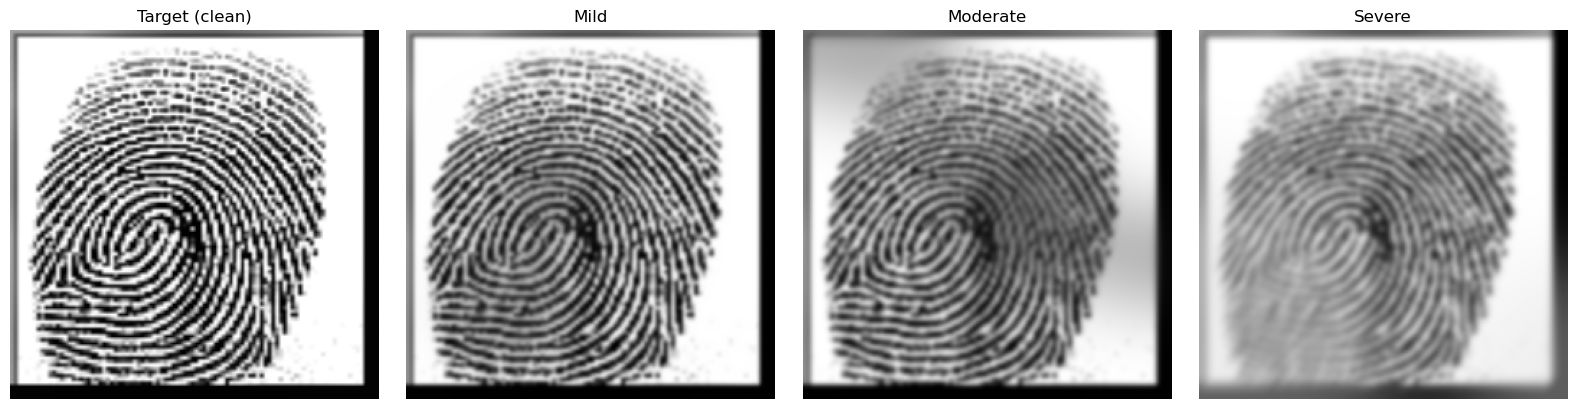

In [10]:
def realistic_smudge_mask(h, w, n_blobs, blob_scale):
    """Irregular soft-edged smudge mask instead of a rectangle. blob_scale controls size."""
    mask = np.zeros((h, w), dtype=np.float32)

    radius = int(min(h, w) * blob_scale)
    for _ in range(n_blobs):
        cx, cy = np.random.randint(0, w), np.random.randint(0, h)
        r = np.random.randint(max(radius // 2, 4), radius)
        cv2.circle(mask, (cx, cy), r, 1.0, -1)

    # feather the edges so it's a gradient, not a hard boundary
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(radius / 3, 2))
    mask = np.clip(mask / mask.max(), 0, 1)
    return mask


def directional_smear(img, angle_deg, length):
    """Motion-blur kernel at a given angle -- mimics a finger sliding across a sensor."""
    length = max(3, length | 1)  # force odd
    kernel = np.zeros((length, length), dtype=np.float32)
    kernel[length // 2, :] = 1.0
    center = (length / 2 - 0.5, length / 2 - 0.5)
    rot_mat = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    kernel = cv2.warpAffine(kernel, rot_mat, (length, length))
    kernel /= kernel.sum()
    return cv2.filter2D(img, -1, kernel)


def degrade(img, level="moderate"):
    latent = img.copy().astype(np.float32)
    h, w = latent.shape

    if level == "mild":
        global_sigma, n_blobs, blob_scale, strength = 1.0, 2, 0.18, 0.45
    elif level == "moderate":
        global_sigma, n_blobs, blob_scale, strength = 1.5, 3, 0.28, 0.70
    else:  # severe
        global_sigma, n_blobs, blob_scale, strength = 2.0, 4, 0.38, 0.90

    # mild overall softening across the whole print (real scans are never perfectly sharp)
    latent = cv2.GaussianBlur(latent, (0, 0), global_sigma)

    # directional smear, mimicking a finger sliding on the sensor
    smear_angle = np.random.uniform(0, 180)
    smear_length = np.random.randint(9, 21)
    smeared = directional_smear(latent, smear_angle, smear_length)

    smudge_mask = realistic_smudge_mask(h, w, n_blobs, blob_scale) * strength

    # randomize wet (dark ink pooling) vs dry (light/faded) smudge character
    if np.random.rand() < 0.5:
        fade_target = np.random.uniform(15, 70)     # wet/dark smear
    else:
        fade_target = np.random.uniform(200, 245)   # dry/faded smear

    latent = latent * (1 - smudge_mask) + (smeared * 0.5 + fade_target * 0.5) * smudge_mask

    return np.clip(latent, 0, 255).astype(np.uint8)

mild = degrade(normalized, "mild")
moderate = degrade(normalized, "moderate")
severe = degrade(normalized, "severe")

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(normalized, cmap="gray"); ax[0].set_title("Target (clean)")
ax[1].imshow(mild, cmap="gray"); ax[1].set_title("Mild")
ax[2].imshow(moderate, cmap="gray"); ax[2].set_title("Moderate")
ax[3].imshow(severe, cmap="gray"); ax[3].set_title("Severe")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

In [11]:
degrade_results = [
    ["Target", *compute_metrics(normalized).values()],
    ["Mild", *compute_metrics(mild).values()],
    ["Moderate", *compute_metrics(moderate).values()],
    ["Severe", *compute_metrics(severe).values()],
]
degrade_df = pd.DataFrame(degrade_results, columns=["Image", "MeanIntensity", "Contrast", "Entropy", "BlurScore"])
print(degrade_df)
degrade_df

      Image  MeanIntensity  Contrast  Entropy  BlurScore
0    Target         154.65     88.82     4.71    2514.55
1      Mild         151.12     78.20     5.01     535.53
2  Moderate         140.34     66.71     5.32     166.20
3    Severe         166.93     55.52     5.06      42.17


,Image,MeanIntensity,Contrast,Entropy,BlurScore
0,Target,154.65,88.82,4.71,2514.55
1,Mild,151.12,78.20,5.01,535.53
2,Moderate,140.34,66.71,5.32,166.20
3,Severe,166.93,55.52,5.06,42.17


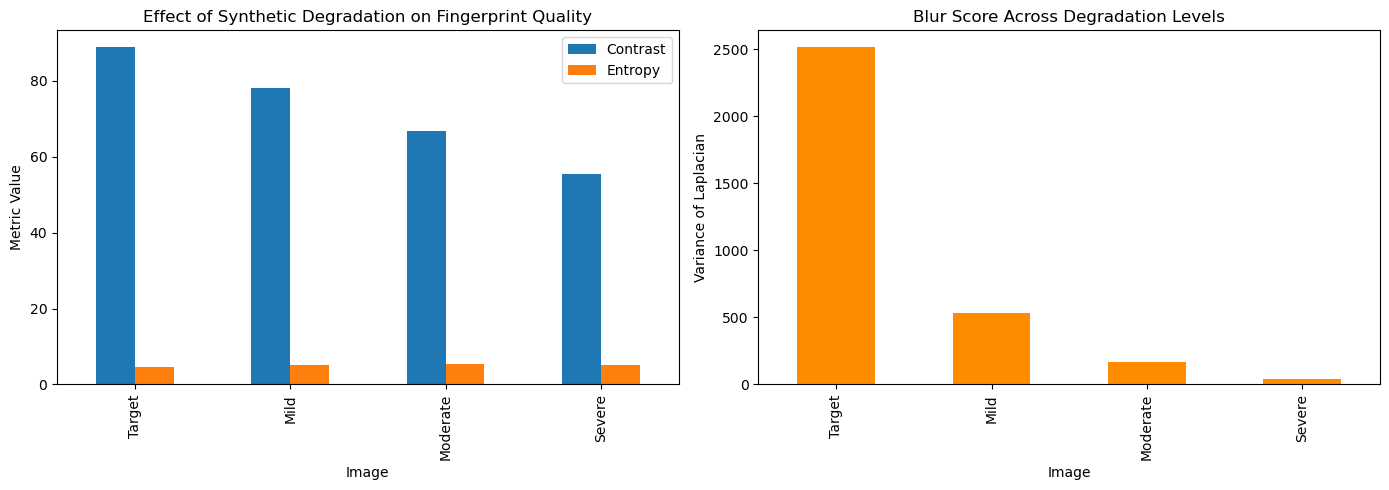

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

degrade_df.plot(x="Image", y=["Contrast", "Entropy"], kind="bar", ax=axes[0])
axes[0].set_title("Effect of Synthetic Degradation on Fingerprint Quality")
axes[0].set_ylabel("Metric Value")

degrade_df.plot(x="Image", y="BlurScore", kind="bar", ax=axes[1], legend=False, color="darkorange")
axes[1].set_title("Blur Score Across Degradation Levels")
axes[1].set_ylabel("Variance of Laplacian")

plt.tight_layout()
plt.show()

## 4. PolyU Noise Library

Extract real sensor noise (`real - mean`) from the PolyU cropped image pairs, then preview a sample noise map and its effect on a fingerprint.

In [13]:
files = list(Path(POLYU_ROOT).rglob("*"))
print("Total PolyU files:", len(files))
for f in files[:5]:
    print(f)

Total PolyU files: 200
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_11_mean.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_11_real.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_14_mean.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_14_real.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_5_mean.JPG


In [14]:
mean_files = sorted(Path(POLYU_ROOT).glob("*_mean.JPG"))
count = 0

for mean_path in mean_files:
    real_path = Path(str(mean_path).replace("_mean.JPG", "_real.JPG"))
    if not real_path.exists():
        continue

    mean_img = cv2.imread(str(mean_path)).astype(np.float32)
    real_img = cv2.imread(str(real_path)).astype(np.float32)

    noise = real_img - mean_img
    np.save(NOISE_LIB_DIR / f"noise_{count:03d}.npy", noise)
    count += 1

print("Noise maps saved:", count)

Noise maps saved: 100


Noise maps available: 100


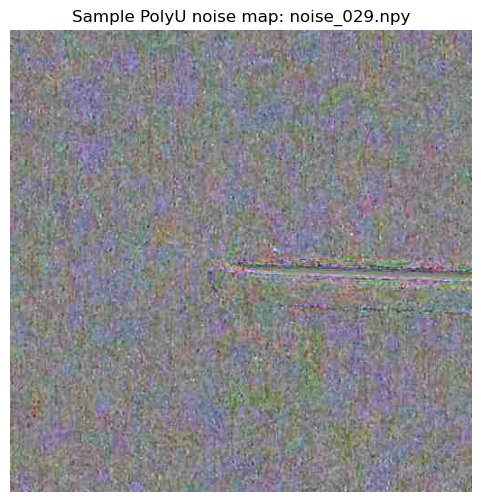

In [15]:
noise_files = list(NOISE_LIB_DIR.glob("*.npy"))
print("Noise maps available:", len(noise_files))

sample_noise_path = random.choice(noise_files)
noise = np.load(sample_noise_path)

display = noise.copy()
display -= display.min()
display /= display.max()
display *= 255
display = display.astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title(f"Sample PolyU noise map: {sample_noise_path.name}")
plt.axis("off")
plt.show()

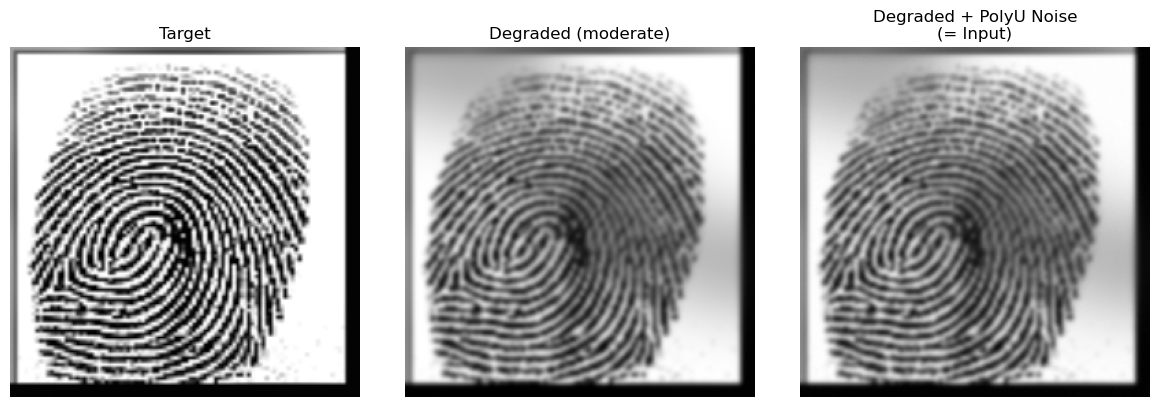

,Image,MeanIntensity,Contrast,Entropy,BlurScore
0,Target,154.65,88.82,4.71,2514.55
1,Degraded,140.34,66.71,5.32,166.20
2,Degraded + Noise (Input),139.80,66.71,5.36,174.95


In [16]:
def add_polyu_noise(img, noise_files):
    noise_path = random.choice(noise_files)
    noise = np.load(noise_path)

    noise = cv2.resize(noise, (IMG_SIZE, IMG_SIZE))
    if noise.ndim == 3:
        noise = cv2.cvtColor(noise, cv2.COLOR_BGR2GRAY)

    alpha = np.random.uniform(0.10, 0.25)
    out = img.astype(np.float32) + alpha * noise
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

noisy_moderate = add_polyu_noise(moderate, noise_files)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(normalized, cmap="gray"); ax[0].set_title("Target")
ax[1].imshow(moderate, cmap="gray"); ax[1].set_title("Degraded (moderate)")
ax[2].imshow(noisy_moderate, cmap="gray"); ax[2].set_title("Degraded + PolyU Noise\n(= Input)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

noise_demo_df = pd.DataFrame([
    ["Target", *compute_metrics(normalized).values()],
    ["Degraded", *compute_metrics(moderate).values()],
    ["Degraded + Noise (Input)", *compute_metrics(noisy_moderate).values()],
], columns=["Image", "MeanIntensity", "Contrast", "Entropy", "BlurScore"])
noise_demo_df

## 5. Full Dataset Generation

Loop over all 6,000 SOCOFing images: build `target/` (clean) and `input/` (degraded + PolyU noise), paired by filename. Degradation level is randomly mixed (25% mild / 50% moderate / 25% severe) so the GAN sees a range of difficulty — set `LEVEL_WEIGHTS` below to change that.

In [17]:
LEVEL_CHOICES = ("mild", "moderate", "severe")
LEVEL_WEIGHTS = (0.25, 0.5, 0.25)  # set e.g. (0, 1, 0) to force all-moderate

def generate_dataset():
    count = 0
    skipped = 0

    subject_folders = sorted(p for p in SOCOFING_ROOT.iterdir() if p.is_dir())

    for subject_folder in subject_folders:
        for img_path in sorted(subject_folder.glob("*.BMP")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                skipped += 1
                continue

            clean = preprocess(img)

            level = random.choices(LEVEL_CHOICES, weights=LEVEL_WEIGHTS, k=1)[0]
            degraded = degrade(clean, level=level)
            degraded = add_polyu_noise(degraded, noise_files)

            fname = f"{count:05d}.png"
            cv2.imwrite(str(TARGET_DIR / fname), clean)
            cv2.imwrite(str(INPUT_DIR / fname), degraded)

            count += 1
            if count % 500 == 0:
                print(f"Processed {count} images...")

    print(f"\nDone. Saved {count} pairs. Skipped {skipped} unreadable files.")
    return count

# Uncomment to run on the full 6,000-image dataset:
# total_generated = generate_dataset()

In [22]:
# def zip_outputs():
#     target_zip = shutil.make_archive("target_images", "zip", root_dir=TARGET_DIR)
#     input_zip = shutil.make_archive("input_images", "zip", root_dir=INPUT_DIR)
#     print(f"Zipped: {target_zip}")
#     print(f"Zipped: {input_zip}")
#     return target_zip, input_zip

# # Uncomment after generate_dataset() has finished:
# # zip_outputs()

## 6. Verification — Sample Pairs & Quality Comparison

Run this **after** `generate_dataset()` has completed, to sanity-check the generated `input/`/`target/` folders and compare quality metrics across the whole dataset.

Target images: 6000
Input images: 6000


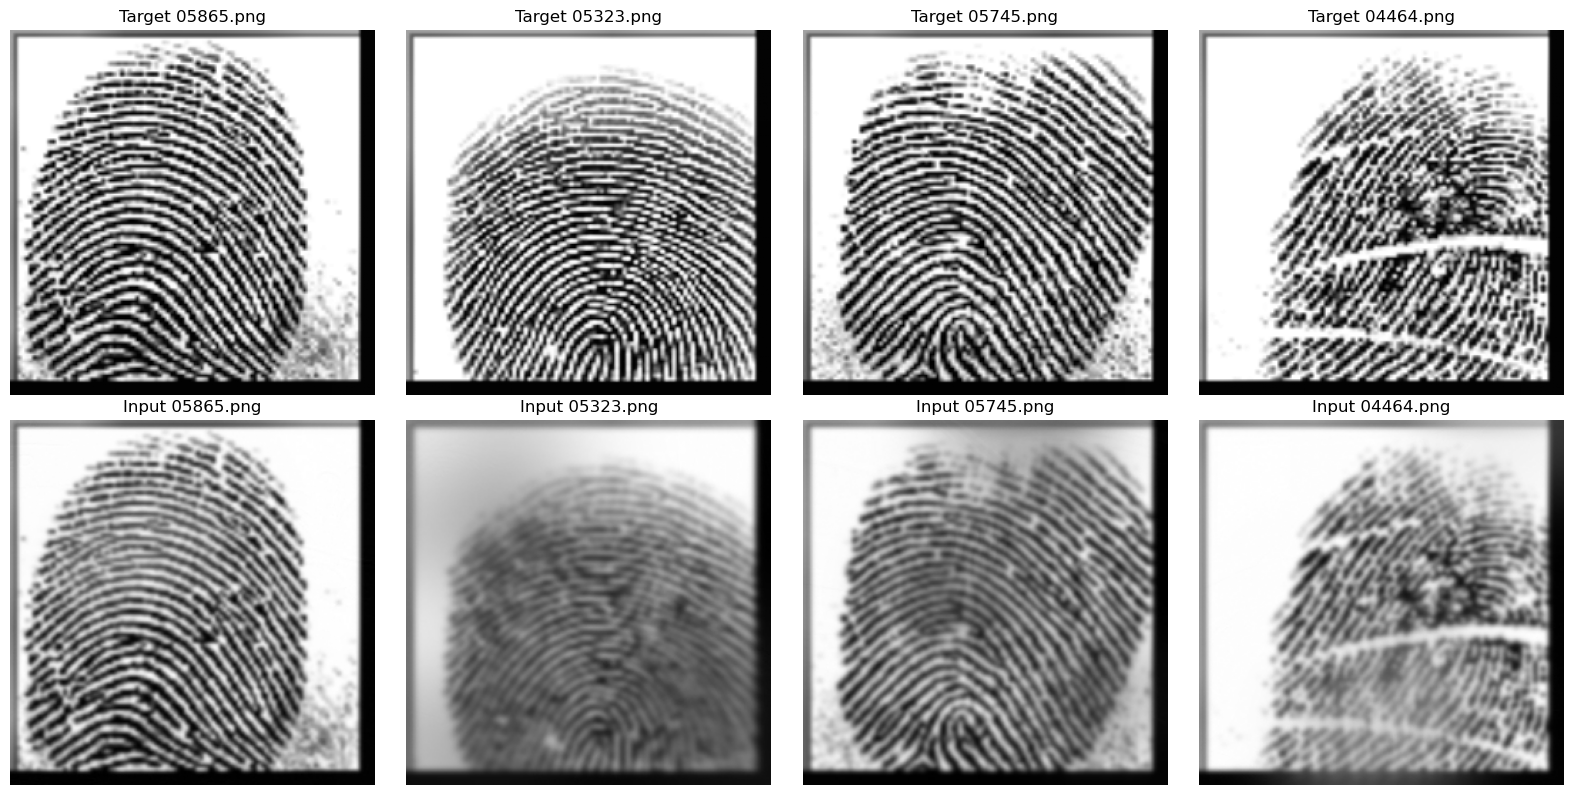

In [23]:
target_files = sorted(TARGET_DIR.glob("*.png"))
input_files = sorted(INPUT_DIR.glob("*.png"))
print("Target images:", len(target_files))
print("Input images:", len(input_files))

sample_ids = random.sample(range(len(target_files)), min(4, len(target_files))) if target_files else []

fig, axes = plt.subplots(2, len(sample_ids), figsize=(4 * len(sample_ids), 8))
for i, idx in enumerate(sample_ids):
    t_img = cv2.imread(str(target_files[idx]), 0)
    i_img = cv2.imread(str(input_files[idx]), 0)

    axes[0, i].imshow(t_img, cmap="gray"); axes[0, i].set_title(f"Target {target_files[idx].name}"); axes[0, i].axis("off")
    axes[1, i].imshow(i_img, cmap="gray"); axes[1, i].set_title(f"Input {input_files[idx].name}"); axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Quality metric comparison: target vs input, across the full generated dataset
target_metrics = [compute_metrics(cv2.imread(str(p), 0)) for p in target_files]
input_metrics = [compute_metrics(cv2.imread(str(p), 0)) for p in input_files]

target_metrics_df = pd.DataFrame(target_metrics)
input_metrics_df = pd.DataFrame(input_metrics)

print("Target quality metrics:")
print(target_metrics_df.describe())
print("\nInput quality metrics:")
print(input_metrics_df.describe())

Target quality metrics:
       MeanIntensity     Contrast      Entropy    BlurScore
count    6000.000000  6000.000000  6000.000000  6000.000000
mean      146.562362    90.386822     4.601185  2037.461655
std        17.936817     4.535786     0.416871   517.777608
min        45.780000    71.640000     2.540000   431.080000
25%       137.107500    87.327500     4.350000  1708.767500
50%       147.710000    89.800000     4.680000  2016.040000
75%       158.172500    92.720000     4.920000  2333.212500
max       208.660000   115.240000     5.370000  5305.500000

Input quality metrics:
       MeanIntensity     Contrast      Entropy    BlurScore
count    6000.000000  6000.000000  6000.000000  6000.000000
mean      143.944100    69.233460     5.170915   204.073233
std        21.227637    10.755779     0.203368   186.374688
min        45.660000    34.350000     3.880000     8.440000
25%       130.480000    62.360000     5.070000    62.847500
50%       145.175000    69.775000     5.220000   145

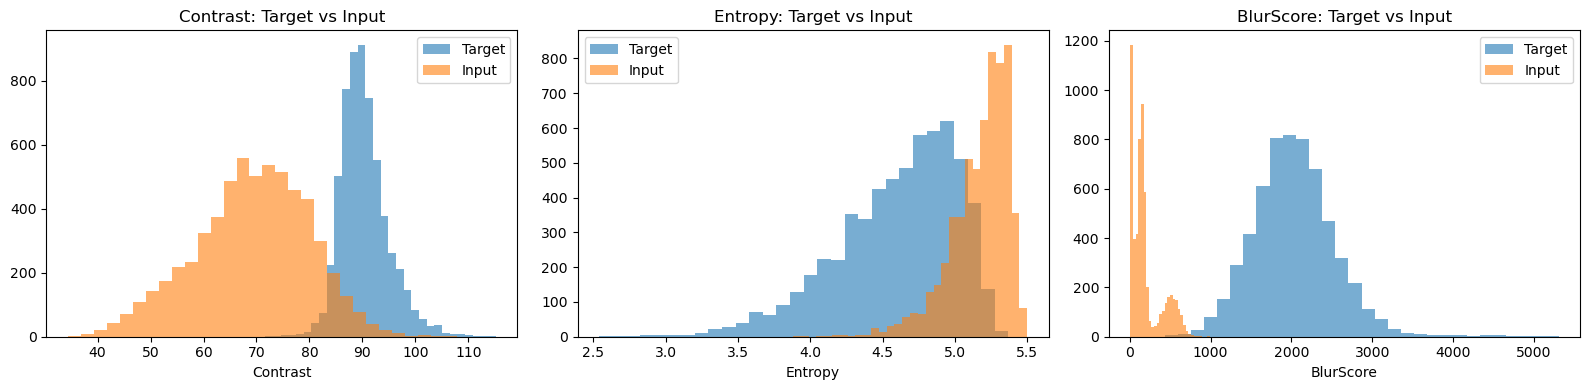

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col, ax in zip(["Contrast", "Entropy", "BlurScore"], axes):
    ax.hist(target_metrics_df[col], bins=30, alpha=0.6, label="Target")
    ax.hist(input_metrics_df[col], bins=30, alpha=0.6, label="Input")
    ax.set_title(f"{col}: Target vs Input")
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()